In [ ]:
!pip install torch
!pip install torchvision
!pip install torchmetrics[image]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from torchmetrics.image.fid import FrechetInceptionDistance
import torchvision.transforms as T
import random
import numpy as np

In [ ]:
# Function to set random seed
def fix_random_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Config
latent_dim = 256
batch_size = 128
fid_batch_size = 100  # Small batch size for FID computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Load Data
transform = transforms.Compose([
    transforms.ToTensor()
])
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
mnist_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)

# Define model components
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, latent_dim)
        )

    def forward(self, x):
        return self.model(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 512), nn.ReLU(),
            nn.Linear(512, 784), nn.Sigmoid()
        )

    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 1), nn.Sigmoid()
        )

    def forward(self, z):
        return self.model(z)

class LatentDiffusionUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

    def forward(self, z):
        return self.net(z)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.91MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.94MB/s]


In [ ]:
# Preprocessing for FID
fid_resize = T.Resize((299, 299))

def preprocess_for_fid(x):
    if x.dtype != torch.float32:
        x = x.float() / 255.0
    x = x.clamp(0, 1)
    x = fid_resize(x)
    x = x.expand(-1, 3, -1, -1)
    x = (x * 255).round().to(torch.uint8)
    return x

In [ ]:
# Load real MNIST test samples
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())
test_loader = DataLoader(mnist_test, batch_size=1000, shuffle=False)
real_imgs, _ = next(iter(test_loader))
real_imgs = real_imgs.to(device)
real_imgs = preprocess_for_fid(real_imgs)

# Run multiple experiments with different seeds
seeds = [42, 123, 2024, 567, 89, 234, 17, 943, 4, 1107]
results = []


=== Running experiment with seed 42 ===
Epoch 1, Recon: 0.0991, D: 0.0243, G: 4.8026, Diff: 0.0080
Epoch 2, Recon: 0.0969, D: 0.0025, G: 6.2784, Diff: 0.0078
Epoch 3, Recon: 0.0981, D: 0.0010, G: 7.3207, Diff: 0.0077
Epoch 4, Recon: 0.0921, D: 0.0009, G: 7.9100, Diff: 0.0077
Epoch 5, Recon: 0.0958, D: 0.0003, G: 8.4532, Diff: 0.0076
Epoch 6, Recon: 0.0982, D: 0.0002, G: 8.8659, Diff: 0.0076
Epoch 7, Recon: 0.0942, D: 0.0002, G: 9.2203, Diff: 0.0077
Epoch 8, Recon: 0.0943, D: 0.0001, G: 9.6474, Diff: 0.0077
Epoch 9, Recon: 0.0865, D: 0.0001, G: 10.0390, Diff: 0.0076
Epoch 10, Recon: 0.0879, D: 0.0001, G: 10.2153, Diff: 0.0076
Epoch 11, Recon: 0.0784, D: 0.0000, G: 10.5705, Diff: 0.0075
Epoch 12, Recon: 0.0802, D: 0.0000, G: 10.7792, Diff: 0.0078
Epoch 13, Recon: 0.0718, D: 0.0000, G: 11.0833, Diff: 0.0077
Epoch 14, Recon: 0.0746, D: 0.0000, G: 11.2191, Diff: 0.0076
Epoch 15, Recon: 0.0746, D: 0.0000, G: 11.4722, Diff: 0.0075
Epoch 16, Recon: 0.0724, D: 0.0000, G: 11.8375, Diff: 0.0076


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 136MB/s]


Seed 42 - FID (Regular AAE vs Real): 0.5322
Seed 42 - FID (Hybrid AAE vs Real): 0.0614


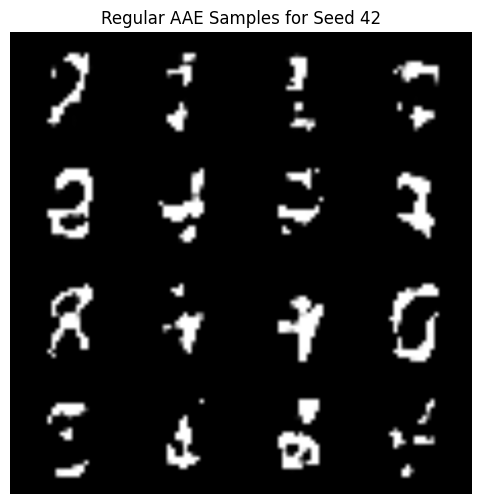

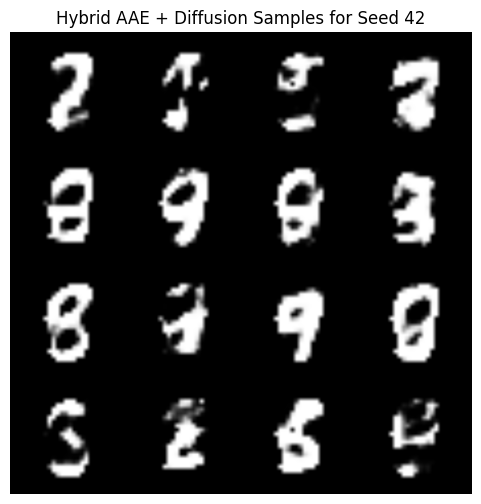


=== Running experiment with seed 123 ===
Epoch 1, Recon: 0.0960, D: 0.0123, G: 4.8333, Diff: 0.0079
Epoch 2, Recon: 0.0957, D: 0.0029, G: 6.5798, Diff: 0.0077
Epoch 3, Recon: 0.0908, D: 0.0017, G: 7.2343, Diff: 0.0075
Epoch 4, Recon: 0.0882, D: 0.0006, G: 7.9390, Diff: 0.0076
Epoch 5, Recon: 0.0943, D: 0.0004, G: 8.4111, Diff: 0.0076
Epoch 6, Recon: 0.0879, D: 0.0002, G: 8.7412, Diff: 0.0076
Epoch 7, Recon: 0.0879, D: 0.0001, G: 9.2751, Diff: 0.0077
Epoch 8, Recon: 0.0878, D: 0.0003, G: 9.6052, Diff: 0.0077
Epoch 9, Recon: 0.0835, D: 0.0001, G: 9.9248, Diff: 0.0076
Epoch 10, Recon: 0.0853, D: 0.0001, G: 10.2929, Diff: 0.0076
Epoch 11, Recon: 0.0769, D: 0.0000, G: 10.4596, Diff: 0.0076
Epoch 12, Recon: 0.0780, D: 0.0000, G: 10.7123, Diff: 0.0076
Epoch 13, Recon: 0.0709, D: 0.0000, G: 11.0167, Diff: 0.0076
Epoch 14, Recon: 0.0748, D: 0.0000, G: 11.3056, Diff: 0.0075
Epoch 15, Recon: 0.0778, D: 0.0000, G: 11.5620, Diff: 0.0076
Epoch 16, Recon: 0.0744, D: 0.0000, G: 11.7761, Diff: 0.0075


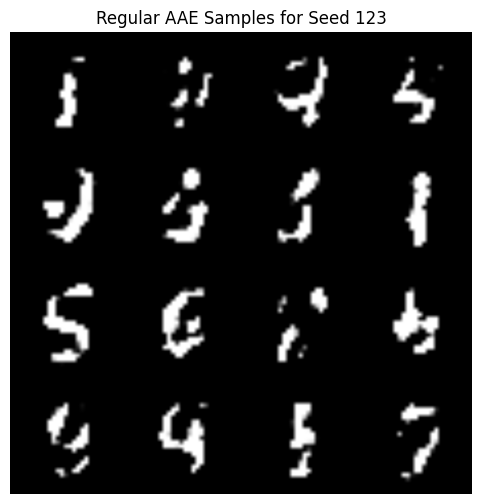

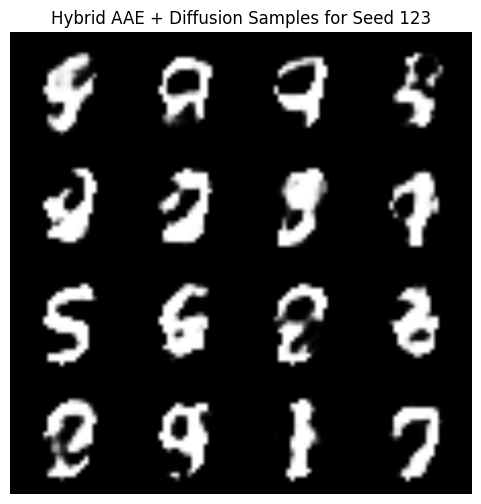


=== Running experiment with seed 2024 ===
Epoch 1, Recon: 0.1030, D: 0.0097, G: 5.0014, Diff: 0.0078
Epoch 2, Recon: 0.0971, D: 0.0028, G: 6.5522, Diff: 0.0075
Epoch 3, Recon: 0.0977, D: 0.0012, G: 7.2858, Diff: 0.0077
Epoch 4, Recon: 0.0980, D: 0.0005, G: 7.9260, Diff: 0.0076
Epoch 5, Recon: 0.0928, D: 0.0003, G: 8.5122, Diff: 0.0077
Epoch 6, Recon: 0.0901, D: 0.0002, G: 8.8517, Diff: 0.0076
Epoch 7, Recon: 0.0879, D: 0.0003, G: 9.2723, Diff: 0.0075
Epoch 8, Recon: 0.0861, D: 0.0002, G: 9.6098, Diff: 0.0076
Epoch 9, Recon: 0.0892, D: 0.0001, G: 9.8941, Diff: 0.0076
Epoch 10, Recon: 0.0834, D: 0.0001, G: 10.3992, Diff: 0.0076
Epoch 11, Recon: 0.0761, D: 0.0000, G: 10.5688, Diff: 0.0075
Epoch 12, Recon: 0.0790, D: 0.0001, G: 10.8991, Diff: 0.0076
Epoch 13, Recon: 0.0730, D: 0.0000, G: 11.1372, Diff: 0.0076
Epoch 14, Recon: 0.0742, D: 0.0000, G: 11.3605, Diff: 0.0075
Epoch 15, Recon: 0.0744, D: 0.0000, G: 11.5933, Diff: 0.0075
Epoch 16, Recon: 0.0721, D: 0.0000, G: 11.8512, Diff: 0.0074

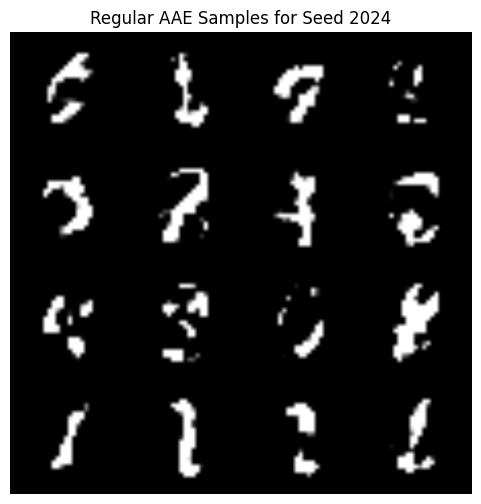

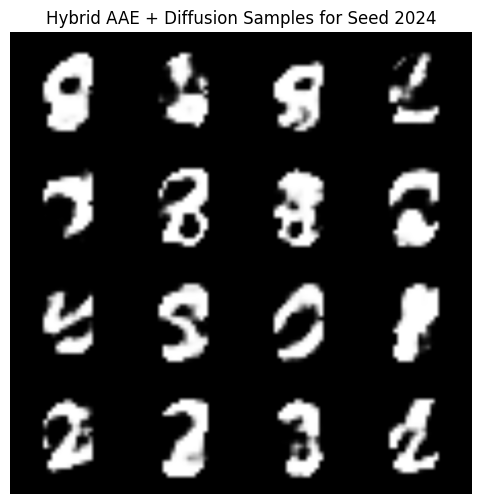


=== Running experiment with seed 567 ===
Epoch 1, Recon: 0.1041, D: 0.0131, G: 4.9497, Diff: 0.0082
Epoch 2, Recon: 0.0989, D: 0.0025, G: 6.4151, Diff: 0.0079
Epoch 3, Recon: 0.0997, D: 0.0009, G: 7.3914, Diff: 0.0078
Epoch 4, Recon: 0.0911, D: 0.0007, G: 7.9172, Diff: 0.0077
Epoch 5, Recon: 0.0909, D: 0.0004, G: 8.3988, Diff: 0.0077
Epoch 6, Recon: 0.0933, D: 0.0002, G: 8.9729, Diff: 0.0077
Epoch 7, Recon: 0.0838, D: 0.0002, G: 9.3258, Diff: 0.0077
Epoch 8, Recon: 0.0872, D: 0.0001, G: 9.5167, Diff: 0.0078
Epoch 9, Recon: 0.0822, D: 0.0001, G: 10.0270, Diff: 0.0078
Epoch 10, Recon: 0.0803, D: 0.0001, G: 10.0456, Diff: 0.0077
Epoch 11, Recon: 0.0881, D: 0.0000, G: 10.5464, Diff: 0.0078
Epoch 12, Recon: 0.0773, D: 0.0000, G: 10.7289, Diff: 0.0076
Epoch 13, Recon: 0.0765, D: 0.0000, G: 11.0940, Diff: 0.0076
Epoch 14, Recon: 0.0678, D: 0.0000, G: 11.2023, Diff: 0.0078
Epoch 15, Recon: 0.0699, D: 0.0000, G: 11.5679, Diff: 0.0077
Epoch 16, Recon: 0.0715, D: 0.0000, G: 11.7934, Diff: 0.0077

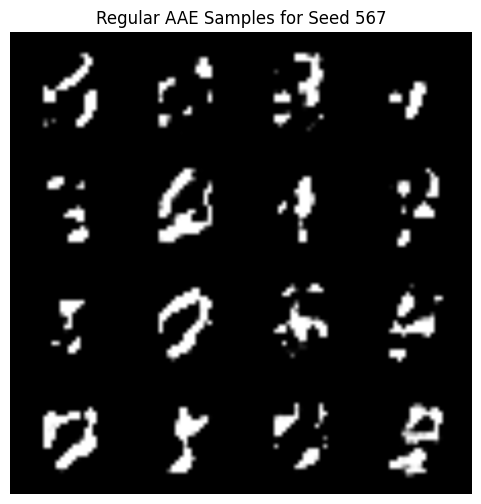

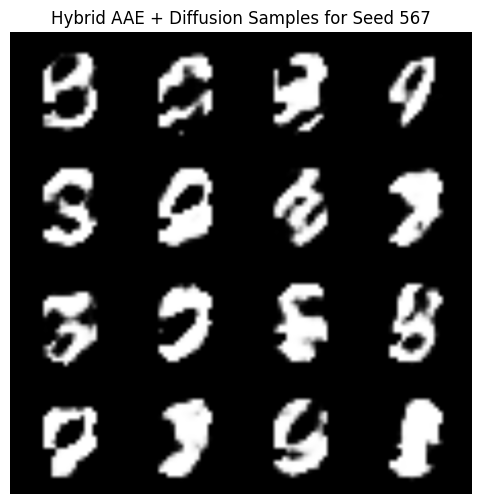


=== Running experiment with seed 89 ===
Epoch 1, Recon: 0.1014, D: 0.0111, G: 5.0341, Diff: 0.0078
Epoch 2, Recon: 0.0963, D: 0.0037, G: 6.4291, Diff: 0.0076
Epoch 3, Recon: 0.0950, D: 0.0009, G: 7.4327, Diff: 0.0076
Epoch 4, Recon: 0.0959, D: 0.0005, G: 8.1580, Diff: 0.0075
Epoch 5, Recon: 0.0872, D: 0.0003, G: 8.4773, Diff: 0.0075
Epoch 6, Recon: 0.0880, D: 0.0002, G: 9.0032, Diff: 0.0075
Epoch 7, Recon: 0.0905, D: 0.0001, G: 9.4197, Diff: 0.0075
Epoch 8, Recon: 0.0834, D: 0.0001, G: 9.6585, Diff: 0.0076
Epoch 9, Recon: 0.0826, D: 0.0001, G: 9.9704, Diff: 0.0075
Epoch 10, Recon: 0.0793, D: 0.0001, G: 10.3101, Diff: 0.0074
Epoch 11, Recon: 0.0817, D: 0.0000, G: 10.6052, Diff: 0.0076
Epoch 12, Recon: 0.0796, D: 0.0000, G: 10.9301, Diff: 0.0075
Epoch 13, Recon: 0.0745, D: 0.0001, G: 11.0685, Diff: 0.0075
Epoch 14, Recon: 0.0809, D: 0.0000, G: 11.3910, Diff: 0.0076
Epoch 15, Recon: 0.0808, D: 0.0000, G: 11.6716, Diff: 0.0074
Epoch 16, Recon: 0.0787, D: 0.0000, G: 11.9749, Diff: 0.0074
E

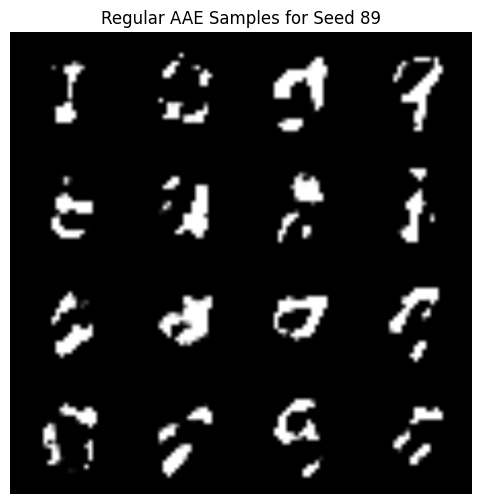

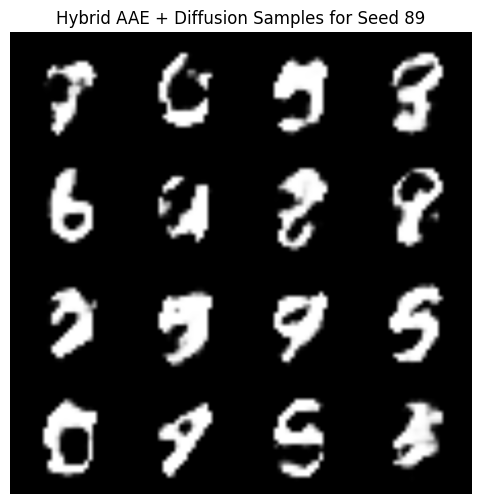


=== Running experiment with seed 234 ===
Epoch 1, Recon: 0.1004, D: 0.0165, G: 4.9411, Diff: 0.0078
Epoch 2, Recon: 0.1000, D: 0.0021, G: 6.5366, Diff: 0.0075
Epoch 3, Recon: 0.0958, D: 0.0012, G: 7.4838, Diff: 0.0075
Epoch 4, Recon: 0.0916, D: 0.0006, G: 8.0358, Diff: 0.0075
Epoch 5, Recon: 0.0837, D: 0.0003, G: 8.5450, Diff: 0.0074
Epoch 6, Recon: 0.0907, D: 0.0002, G: 9.0345, Diff: 0.0074
Epoch 7, Recon: 0.0887, D: 0.0001, G: 9.4043, Diff: 0.0073
Epoch 8, Recon: 0.0815, D: 0.0002, G: 9.6166, Diff: 0.0075
Epoch 9, Recon: 0.0845, D: 0.0001, G: 9.9906, Diff: 0.0074
Epoch 10, Recon: 0.0814, D: 0.0000, G: 10.3578, Diff: 0.0074
Epoch 11, Recon: 0.0759, D: 0.0000, G: 10.5713, Diff: 0.0073
Epoch 12, Recon: 0.0784, D: 0.0000, G: 10.8827, Diff: 0.0075
Epoch 13, Recon: 0.0697, D: 0.0000, G: 11.0074, Diff: 0.0072
Epoch 14, Recon: 0.0704, D: 0.0000, G: 11.3334, Diff: 0.0073
Epoch 15, Recon: 0.0713, D: 0.0000, G: 11.7406, Diff: 0.0074
Epoch 16, Recon: 0.0732, D: 0.0000, G: 12.0359, Diff: 0.0074


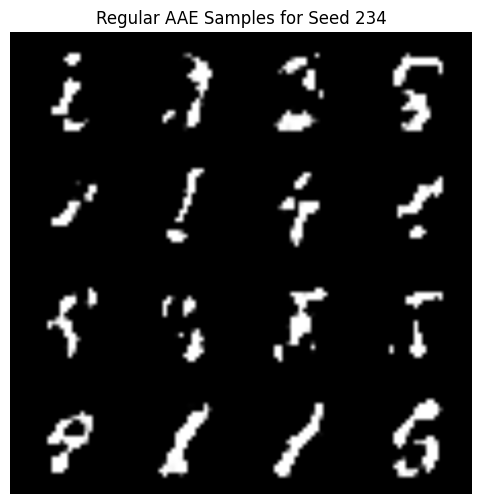

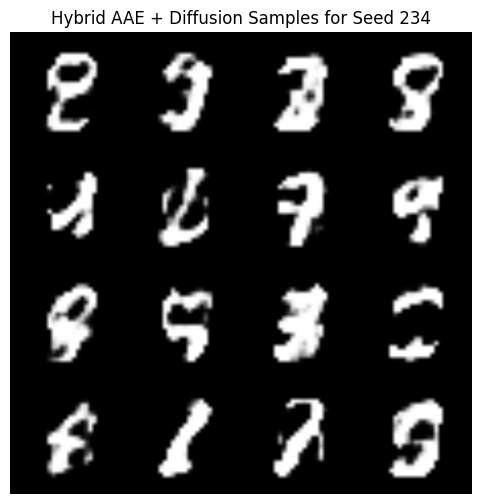


=== Running experiment with seed 17 ===
Epoch 1, Recon: 0.1005, D: 0.0105, G: 4.8192, Diff: 0.0080
Epoch 2, Recon: 0.0923, D: 0.0024, G: 6.4039, Diff: 0.0077
Epoch 3, Recon: 0.0854, D: 0.0009, G: 7.4875, Diff: 0.0077
Epoch 4, Recon: 0.0917, D: 0.0008, G: 8.0075, Diff: 0.0078
Epoch 5, Recon: 0.0867, D: 0.0003, G: 8.6404, Diff: 0.0074
Epoch 6, Recon: 0.0814, D: 0.0002, G: 8.8620, Diff: 0.0077
Epoch 7, Recon: 0.0829, D: 0.0001, G: 9.3317, Diff: 0.0076
Epoch 8, Recon: 0.0839, D: 0.0001, G: 9.6982, Diff: 0.0077
Epoch 9, Recon: 0.0692, D: 0.0001, G: 9.9562, Diff: 0.0075
Epoch 10, Recon: 0.0749, D: 0.0001, G: 10.1924, Diff: 0.0077
Epoch 11, Recon: 0.0744, D: 0.0000, G: 10.7155, Diff: 0.0076
Epoch 12, Recon: 0.0743, D: 0.0000, G: 10.8364, Diff: 0.0076
Epoch 13, Recon: 0.0703, D: 0.0000, G: 11.1386, Diff: 0.0074
Epoch 14, Recon: 0.0717, D: 0.0000, G: 11.3291, Diff: 0.0076
Epoch 15, Recon: 0.0734, D: 0.0000, G: 11.7068, Diff: 0.0077
Epoch 16, Recon: 0.0657, D: 0.0000, G: 11.9765, Diff: 0.0075
E

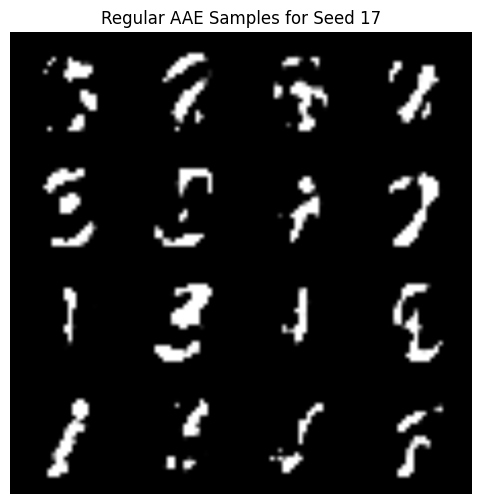

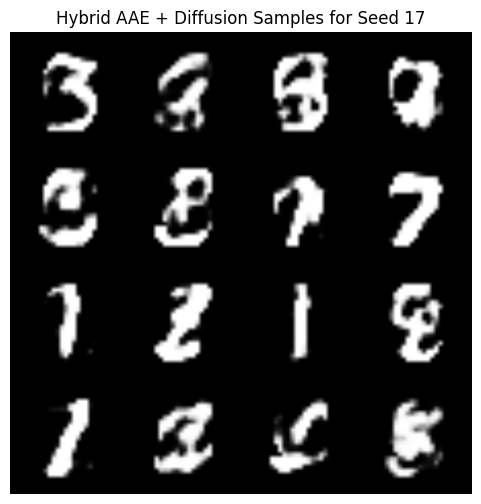


=== Running experiment with seed 943 ===
Epoch 1, Recon: 0.1142, D: 0.0128, G: 4.7368, Diff: 0.0081
Epoch 2, Recon: 0.0996, D: 0.0027, G: 6.3560, Diff: 0.0078
Epoch 3, Recon: 0.0964, D: 0.0013, G: 7.1516, Diff: 0.0077
Epoch 4, Recon: 0.0870, D: 0.0007, G: 7.8924, Diff: 0.0076
Epoch 5, Recon: 0.0849, D: 0.0005, G: 8.4249, Diff: 0.0076
Epoch 6, Recon: 0.0970, D: 0.0002, G: 8.8573, Diff: 0.0075
Epoch 7, Recon: 0.0871, D: 0.0002, G: 9.2209, Diff: 0.0076
Epoch 8, Recon: 0.0870, D: 0.0001, G: 9.5511, Diff: 0.0076
Epoch 9, Recon: 0.0753, D: 0.0001, G: 9.8164, Diff: 0.0075
Epoch 10, Recon: 0.0802, D: 0.0001, G: 10.1385, Diff: 0.0076
Epoch 11, Recon: 0.0801, D: 0.0001, G: 10.4925, Diff: 0.0075
Epoch 12, Recon: 0.0737, D: 0.0000, G: 10.6713, Diff: 0.0074
Epoch 13, Recon: 0.0820, D: 0.0000, G: 11.0791, Diff: 0.0075
Epoch 14, Recon: 0.0765, D: 0.0000, G: 11.2800, Diff: 0.0076
Epoch 15, Recon: 0.0708, D: 0.0000, G: 11.5255, Diff: 0.0076
Epoch 16, Recon: 0.0680, D: 0.0000, G: 11.7638, Diff: 0.0075


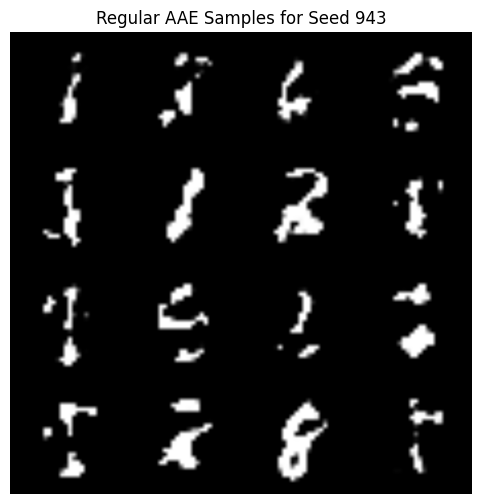

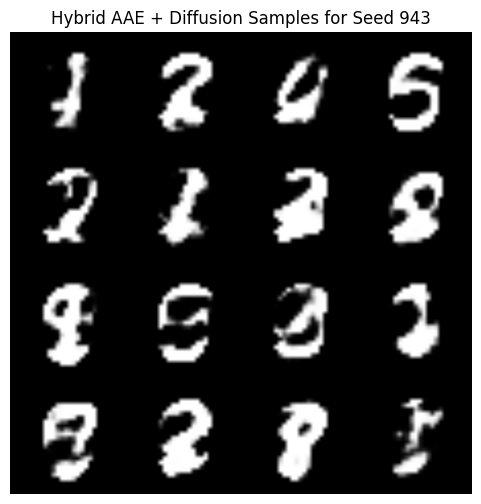


=== Running experiment with seed 4 ===
Epoch 1, Recon: 0.0980, D: 0.0148, G: 4.8678, Diff: 0.0080
Epoch 2, Recon: 0.1008, D: 0.0021, G: 6.5943, Diff: 0.0078
Epoch 3, Recon: 0.0982, D: 0.0008, G: 7.5726, Diff: 0.0077
Epoch 4, Recon: 0.0950, D: 0.0006, G: 8.1317, Diff: 0.0078
Epoch 5, Recon: 0.0880, D: 0.0004, G: 8.4376, Diff: 0.0078
Epoch 6, Recon: 0.0929, D: 0.0002, G: 9.0443, Diff: 0.0077
Epoch 7, Recon: 0.0900, D: 0.0002, G: 9.3861, Diff: 0.0078
Epoch 8, Recon: 0.0805, D: 0.0001, G: 9.6899, Diff: 0.0077
Epoch 9, Recon: 0.0873, D: 0.0001, G: 10.0262, Diff: 0.0076
Epoch 10, Recon: 0.0805, D: 0.0000, G: 10.3569, Diff: 0.0077
Epoch 11, Recon: 0.0823, D: 0.0000, G: 10.6980, Diff: 0.0076
Epoch 12, Recon: 0.0715, D: 0.0000, G: 10.9975, Diff: 0.0076
Epoch 13, Recon: 0.0731, D: 0.0000, G: 11.0460, Diff: 0.0076
Epoch 14, Recon: 0.0716, D: 0.0000, G: 11.2333, Diff: 0.0076
Epoch 15, Recon: 0.0747, D: 0.0000, G: 11.7029, Diff: 0.0076
Epoch 16, Recon: 0.0739, D: 0.0000, G: 11.8667, Diff: 0.0077
E

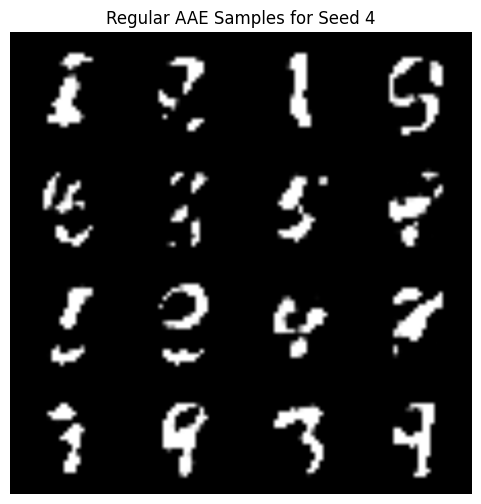

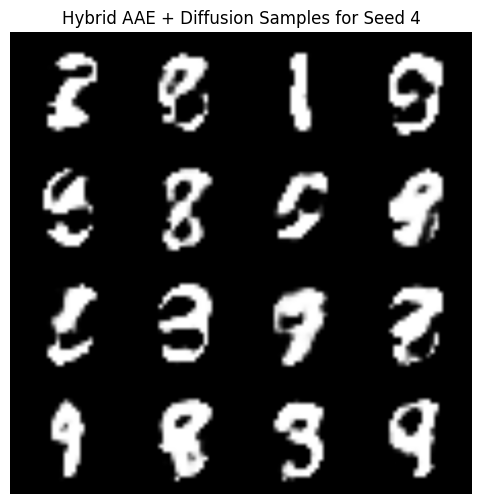


=== Running experiment with seed 1107 ===
Epoch 1, Recon: 0.1034, D: 0.0102, G: 5.0046, Diff: 0.0082
Epoch 2, Recon: 0.1052, D: 0.0017, G: 6.6823, Diff: 0.0080
Epoch 3, Recon: 0.0959, D: 0.0013, G: 7.3893, Diff: 0.0080
Epoch 4, Recon: 0.0915, D: 0.0005, G: 8.0844, Diff: 0.0079
Epoch 5, Recon: 0.0931, D: 0.0003, G: 8.5511, Diff: 0.0079
Epoch 6, Recon: 0.0876, D: 0.0002, G: 8.9840, Diff: 0.0078
Epoch 7, Recon: 0.0868, D: 0.0001, G: 9.3798, Diff: 0.0079
Epoch 8, Recon: 0.0834, D: 0.0001, G: 9.7015, Diff: 0.0080
Epoch 9, Recon: 0.0778, D: 0.0001, G: 9.9243, Diff: 0.0079
Epoch 10, Recon: 0.0813, D: 0.0001, G: 10.3073, Diff: 0.0079
Epoch 11, Recon: 0.0765, D: 0.0000, G: 10.6443, Diff: 0.0080
Epoch 12, Recon: 0.0739, D: 0.0000, G: 10.8481, Diff: 0.0078
Epoch 13, Recon: 0.0716, D: 0.0000, G: 11.1609, Diff: 0.0077
Epoch 14, Recon: 0.0734, D: 0.0000, G: 11.4684, Diff: 0.0079
Epoch 15, Recon: 0.0750, D: 0.0000, G: 11.5694, Diff: 0.0077
Epoch 16, Recon: 0.0674, D: 0.0000, G: 11.8363, Diff: 0.0078

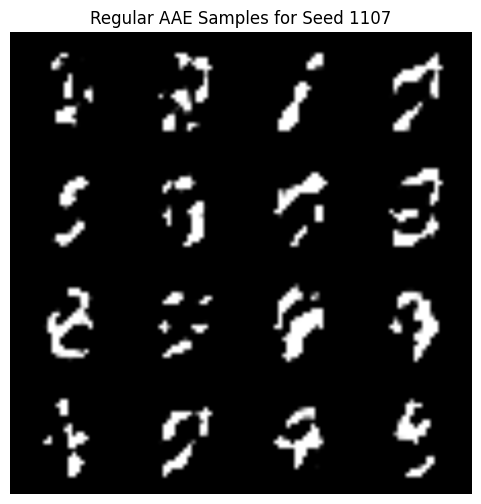

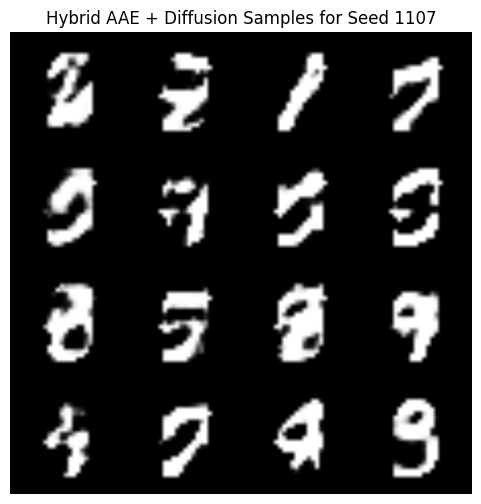

In [ ]:
for run_seed in seeds:
    print(f"\n=== Running experiment with seed {run_seed} ===")
    fix_random_seed(run_seed)

    # Initialize models
    encoder = Encoder().to(device)
    decoder = Decoder().to(device)
    discriminator = Discriminator().to(device)
    diffusion = LatentDiffusionUNet().to(device)

    # Optimizers
    opt_enc_dec = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)
    opt_disc = torch.optim.Adam(discriminator.parameters(), lr=1e-3)
    opt_diff = torch.optim.Adam(diffusion.parameters(), lr=1e-3)

    # Training Loop
    epochs = 20
    for epoch in range(epochs):
        for x, _ in mnist_loader:
            x = x.to(device)
            x = x.view(x.size(0), -1)

            # Reconstruction
            z = encoder(x)
            # Add noise to the latent vector
            z = z.detach() + 0.1 * torch.randn_like(z)
            x_recon = decoder(z)
            recon_loss = F.l1_loss(x_recon, x)

            # Adversarial
            z_real = torch.randn(x.size(0), latent_dim).to(device)
            d_real = discriminator(z_real)
            d_fake = discriminator(z.detach())
            d_loss = -torch.mean(torch.log(d_real + 1e-6) + torch.log(1 - d_fake + 1e-6))

            opt_disc.zero_grad()
            d_loss.backward()
            opt_disc.step()

            d_fake = discriminator(z)
            g_loss = -torch.mean(torch.log(d_fake + 1e-6))

            total_loss = recon_loss + g_loss
            opt_enc_dec.zero_grad()
            total_loss.backward()
            opt_enc_dec.step()

            # Diffusion
            z_noisy = z.detach() + 0.1 * torch.randn_like(z)
            z_denoised = diffusion(z_noisy)
            diffusion_loss = F.mse_loss(z_denoised, z.detach())
            opt_diff.zero_grad()
            diffusion_loss.backward()
            opt_diff.step()

        print(f"Epoch {epoch+1}, Recon: {recon_loss.item():.4f}, D: {d_loss.item():.4f}, G: {g_loss.item():.4f}, Diff: {diffusion_loss.item():.4f}")

    # Evaluation
    encoder.eval()
    decoder.eval()
    diffusion.eval()

    z_samples = torch.randn(1000, latent_dim).to(device)
    x_reg = decoder(z_samples).view(-1, 1, 28, 28)
    z_hybrid = diffusion(z_samples)
    x_hybrid = decoder(z_hybrid).view(-1, 1, 28, 28)

    x_reg = preprocess_for_fid(x_reg)
    x_hybrid = preprocess_for_fid(x_hybrid)

    fid_reg = FrechetInceptionDistance(feature=64).to(device)
    fid_hybrid = FrechetInceptionDistance(feature=64).to(device)

    for i in range(0, real_imgs.size(0), fid_batch_size):
        real_batch = real_imgs[i:i+fid_batch_size].to(device)
        reg_batch = x_reg[i:i+fid_batch_size].to(device)
        hybrid_batch = x_hybrid[i:i+fid_batch_size].to(device)

        fid_reg.update(real_batch, real=True)
        fid_reg.update(reg_batch, real=False)

        fid_hybrid.update(real_batch, real=True)
        fid_hybrid.update(hybrid_batch, real=False)

    fid_reg_score = fid_reg.compute()
    fid_hybrid_score = fid_hybrid.compute()

    print(f"Seed {run_seed} - FID (Regular AAE vs Real): {fid_reg_score:.4f}")
    print(f"Seed {run_seed} - FID (Hybrid AAE vs Real): {fid_hybrid_score:.4f}")

    results.append((run_seed, fid_reg_score.item(), fid_hybrid_score.item()))

    # Visualize Regular AAE samples
    grid = vutils.make_grid(x_reg[:16].cpu().float(), nrow=4, normalize=True)
    plt.figure(figsize=(6,6))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(f"Regular AAE Samples for Seed {run_seed}")
    plt.axis("off")
    plt.show()

    # Visualize Hybrid AAE samples
    grid = vutils.make_grid(x_hybrid[:16].cpu().float(), nrow=4, normalize=True)
    plt.figure(figsize=(6,6))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(f"Hybrid AAE + Diffusion Samples for Seed {run_seed}")
    plt.axis("off")
    plt.show()

In [ ]:
# Summary of results
print("\n=== Summary of all runs ===")
avg_reg_fid = 0
avg_hybrid_fid = 0
for run_seed, reg_fid, hybrid_fid in results:
    print(f"Seed {run_seed}: Regular AAE FID = {reg_fid:.4f}, Hybrid AAE FID = {hybrid_fid:.4f}")
    avg_reg_fid += reg_fid
    avg_hybrid_fid += hybrid_fid
print()
print(f"Average Regular AAE FID = {avg_reg_fid/len(results)}")
print(f"Average Hybrid AAE FID = {avg_hybrid_fid/len(results)}")


=== Summary of all runs ===
Seed 42: Regular AAE FID = 0.5322, Hybrid AAE FID = 0.0614
Seed 123: Regular AAE FID = 0.3673, Hybrid AAE FID = 0.0731
Seed 2024: Regular AAE FID = 0.3810, Hybrid AAE FID = 0.1214
Seed 567: Regular AAE FID = 0.3723, Hybrid AAE FID = 0.1325
Seed 89: Regular AAE FID = 0.3380, Hybrid AAE FID = 0.0955
Seed 234: Regular AAE FID = 0.3926, Hybrid AAE FID = 0.0734
Seed 17: Regular AAE FID = 0.3019, Hybrid AAE FID = 0.1310
Seed 943: Regular AAE FID = 0.3354, Hybrid AAE FID = 0.0907
Seed 4: Regular AAE FID = 0.3531, Hybrid AAE FID = 0.0582
Seed 1107: Regular AAE FID = 0.3683, Hybrid AAE FID = 0.0730

Average Regular AAE FID = 0.37420054376125333
Average Hybrid AAE FID = 0.09102583825588226
